# 난임 시술 임신 성공 예측 — EDA
- train: 256,351행 / 69컬럼 (ID + 67 피처 + 타겟)
- test:  90,067행 / 68컬럼
- 타겟: `임신 성공 여부` (0/1 이진 분류)

train: (256351, 69)  /  test: (90067, 68)


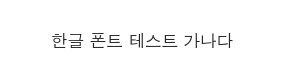

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = '../data/raw/'
TARGET = '임신 성공 여부'
ID_COL = 'ID'

train = pd.read_csv(DATA_DIR + 'train.csv')
test  = pd.read_csv(DATA_DIR + 'test.csv')

print(f'train: {train.shape}  /  test: {test.shape}')

# 폰트 확인
# fig, ax = plt.subplots(figsize=(3, 1))
# ax.text(0.5, 0.5, '한글 폰트 테스트 가나다', ha='center', va='center', fontsize=12)
# ax.axis('off')
# plt.tight_layout()
# plt.show()

## 1. 기본 정보

In [2]:
train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  object 
 1   시술 시기 코드               256351 non-null  object 
 2   시술 당시 나이               256351 non-null  object 
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  object 
 5   특정 시술 유형               256349 non-null  object 
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  object 
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             256351 non-null  int64  
 14  여성 부 불임 원인             256351 non-nu

In [3]:
train.head(3)

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0


In [4]:
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET]]
num_cols = train[feature_cols].select_dtypes(include='number').columns.tolist()
cat_cols = train[feature_cols].select_dtypes(exclude='number').columns.tolist()

print(f'수치형 피처: {len(num_cols)}개')
print(f'범주형 피처: {len(cat_cols)}개')
print()
print('수치형:', num_cols)
print()
print('범주형:', cat_cols)

수치형 피처: 47개
범주형 피처: 20개

수치형: ['임신 시도 또는 마지막 임신 경과 연수', '배란 자극 여부', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일', '난자 해동 경과일', '난자 혼합 경과일', '배아 이식 경과일', '배아 해동 경과일']

범주형: ['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 유도 유형', '배아 생성 주요 이유', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이'

## 2. 타겟 분포 (클래스 불균형 확인)

임신 성공 여부 분포
           count  ratio(%)
임신 성공 여부                  
0         190123     74.17
1          66228     25.83


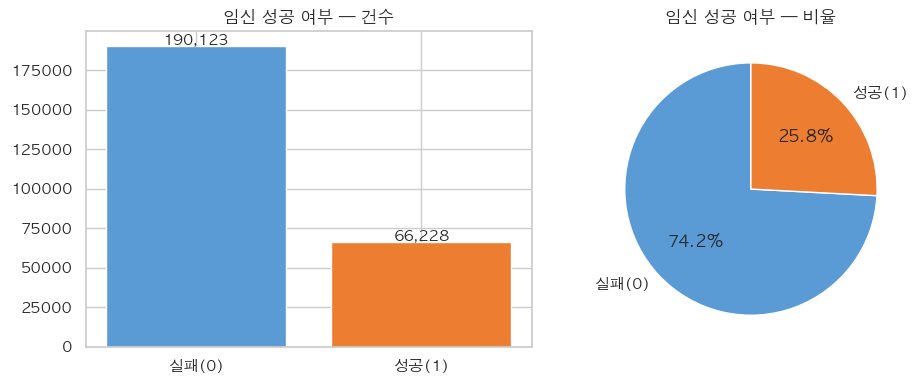

In [5]:
target_counts = train[TARGET].value_counts()
target_ratio  = train[TARGET].value_counts(normalize=True) * 100

print('임신 성공 여부 분포')
print(pd.DataFrame({'count': target_counts, 'ratio(%)': target_ratio.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['실패(0)', '성공(1)'], target_counts.values, color=['#5B9BD5', '#ED7D31'])
axes[0].set_title('임신 성공 여부 — 건수')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(target_counts.values, labels=['실패(0)', '성공(1)'],
            autopct='%1.1f%%', colors=['#5B9BD5', '#ED7D31'], startangle=90)
axes[1].set_title('임신 성공 여부 — 비율')

plt.tight_layout()
plt.show()

## 3. 결측치 분석

In [6]:
def missing_summary(df, label='train'):
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    ratio = (miss / len(df) * 100).round(2)
    result = pd.DataFrame({'결측 수': miss, '결측률(%)': ratio})
    print(f'[{label}] 결측 있는 컬럼: {len(result)}개')
    return result

train_miss = missing_summary(train, 'train')
print(train_miss.to_string())

[train] 결측 있는 컬럼: 31개
                         결측 수  결측률(%)
난자 해동 경과일              254915   99.44
PGS 시술 여부              254422   99.25
PGD 시술 여부              254172   99.15
착상 전 유전 검사 사용 여부       253633   98.94
임신 시도 또는 마지막 임신 경과 연수  246981   96.34
배아 해동 경과일              215982   84.25
난자 채취 경과일               57488   22.43
난자 혼합 경과일               53735   20.96
배아 이식 경과일               43566   16.99
총 생성 배아 수                6291    2.45
기증자 정자와 혼합된 난자 수         6291    2.45
단일 배아 이식 여부              6291    2.45
착상 전 유전 진단 사용 여부         6291    2.45
배아 생성 주요 이유              6291    2.45
대리모 여부                   6291    2.45
기증 배아 사용 여부              6291    2.45
신선 배아 사용 여부              6291    2.45
동결 배아 사용 여부              6291    2.45
파트너 정자와 혼합된 난자 수         6291    2.45
미세주입된 난자 수               6291    2.45
혼합된 난자 수                 6291    2.45
저장된 신선 난자 수              6291    2.45
해동 난자 수                  6291    2.45
해동된 배아 수                 6291    2.45
미세주입 후 저장된 배아 수          629

In [7]:
test_miss = missing_summary(test, 'test')
print(test_miss.to_string())

[test] 결측 있는 컬럼: 30개
                        결측 수  결측률(%)
난자 해동 경과일              89575   99.45
PGS 시술 여부              89396   99.25
PGD 시술 여부              89286   99.13
착상 전 유전 검사 사용 여부       89134   98.96
임신 시도 또는 마지막 임신 경과 연수  86770   96.34
배아 해동 경과일              76117   84.51
난자 채취 경과일              19949   22.15
난자 혼합 경과일              18579   20.63
배아 이식 경과일              15246   16.93
미세주입된 난자 수              2176    2.42
미세주입에서 생성된 배아 수         2176    2.42
착상 전 유전 진단 사용 여부        2176    2.42
배아 생성 주요 이유             2176    2.42
총 생성 배아 수               2176    2.42
대리모 여부                  2176    2.42
기증 배아 사용 여부             2176    2.42
신선 배아 사용 여부             2176    2.42
동결 배아 사용 여부             2176    2.42
기증자 정자와 혼합된 난자 수        2176    2.42
파트너 정자와 혼합된 난자 수        2176    2.42
혼합된 난자 수                2176    2.42
단일 배아 이식 여부             2176    2.42
수집된 신선 난자 수             2176    2.42
해동 난자 수                 2176    2.42
해동된 배아 수                2176    2.42
미세주입 후 저장된 배아 수  

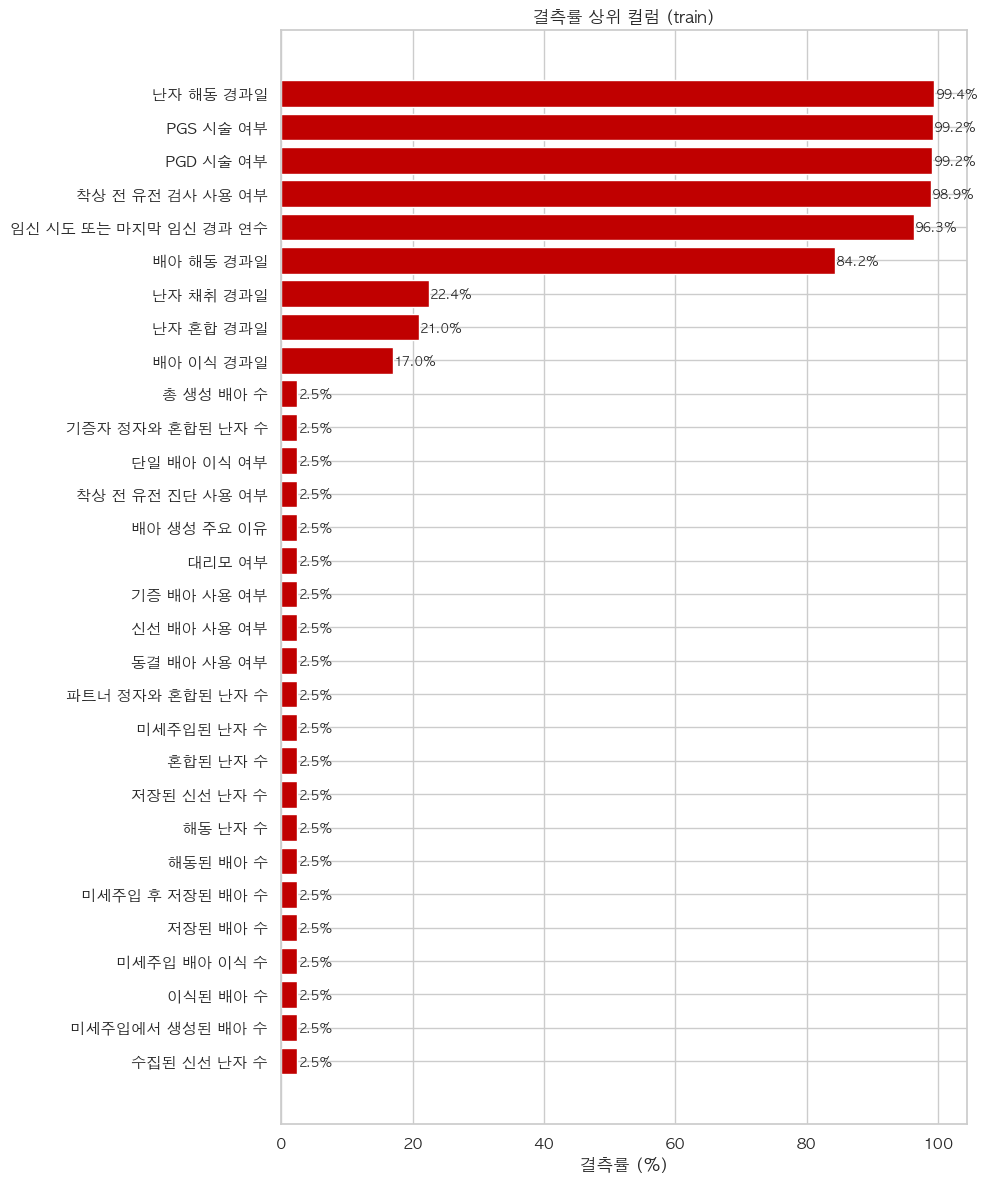

In [8]:
top_miss = train_miss.head(30)
if len(top_miss) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(top_miss) * 0.4)))
    ax.barh(top_miss.index[::-1], top_miss['결측률(%)'][::-1], color='#C00000')
    ax.set_xlabel('결측률 (%)')
    ax.set_title('결측률 상위 컬럼 (train)')
    for i, v in enumerate(top_miss['결측률(%)'][::-1]):
        ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('결측치 없음')

### 결측값 해석 주의 컬럼

아래 컬럼들은 결측을 단순 누락이 아닌 **"미시행(=0)"** 으로 해석해야 함:

| 컬럼 | 비결측 건수 | 비결측값 | 해석 |
|---|---|---|---|
| `착상 전 유전 검사 사용 여부` | 2,718행 | 전부 1 | 결측 = PGS 미시행(0) |
| `PGD 시술 여부` | 2,179행 | 전부 1 | 결측 = PGD 미시행(0) |
| `PGS 시술 여부` | 1,929행 | 전부 1 | 결측 = PGS 미시행(0) |

→ 피처 엔지니어링 단계에서 **결측=0으로 재코딩** 후 이진 변수로 활용 권장.  
→ `불임 원인 - 여성 요인`은 전체가 0인 **상수 컬럼**으로 피처에서 제외 필요.

## 4. 수치형 변수 분석

In [9]:
train[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
임신 시도 또는 마지막 임신 경과 연수,9370.0,9.27,3.55,0.0,7.0,9.0,11.0,20.0
배란 자극 여부,256351.0,0.77,0.42,0.0,1.0,1.0,1.0,1.0
단일 배아 이식 여부,250060.0,0.23,0.42,0.0,0.0,0.0,0.0,1.0
착상 전 유전 검사 사용 여부,2718.0,1.00,0.00,1.0,1.0,1.0,1.0,1.0
착상 전 유전 진단 사용 여부,250060.0,0.01,0.11,0.0,0.0,0.0,0.0,1.0
남성 주 불임 원인,256351.0,0.03,0.17,0.0,0.0,0.0,0.0,1.0
남성 부 불임 원인,256351.0,0.01,0.11,0.0,0.0,0.0,0.0,1.0
여성 주 불임 원인,256351.0,0.03,0.17,0.0,0.0,0.0,0.0,1.0
여성 부 불임 원인,256351.0,0.01,0.11,0.0,0.0,0.0,0.0,1.0
부부 주 불임 원인,256351.0,0.03,0.18,0.0,0.0,0.0,0.0,1.0


In [ ]:
# 상수 컬럼 및 비결측값이 단일값인 컬럼 진단
print('=== 상수/단일값 컬럼 진단 ===')
print()

# 전체가 동일한 값 (표준편차 = 0, 결측 포함)
const_cols = [c for c in num_cols if train[c].std() == 0]
print(f'[완전 상수 컬럼 — std=0] {len(const_cols)}개')
for col in const_cols:
    unique_val = train[col].dropna().unique().tolist()
    n_notnull = train[col].notna().sum()
    print(f'  {col}: 비결측 {n_notnull:,}행, 유일값 = {unique_val}  → 예측에 사용 불가')

print()

# 비결측값만 보면 단일값인 컬럼 (결측이 "미시행"을 의미할 가능성)
single_val_after_dropna = []
for col in num_cols:
    notnull_unique = train[col].dropna().unique()
    if len(notnull_unique) == 1 and col not in const_cols:
        single_val_after_dropna.append(col)

print(f'[비결측값이 단일값인 컬럼 — 결측=미시행(0) 가능성] {len(single_val_after_dropna)}개')
for col in single_val_after_dropna:
    unique_val = train[col].dropna().unique().tolist()
    n_notnull = train[col].notna().sum()
    miss_rate = train[col].isna().mean() * 100
    print(f'  {col}: 비결측 {n_notnull:,}행(결측률 {miss_rate:.1f}%), 유일값 = {unique_val}')
    print(f'    → 단순 결측 처리보다 결측=0 으로 재코딩 후 이진 변수로 활용 권장')

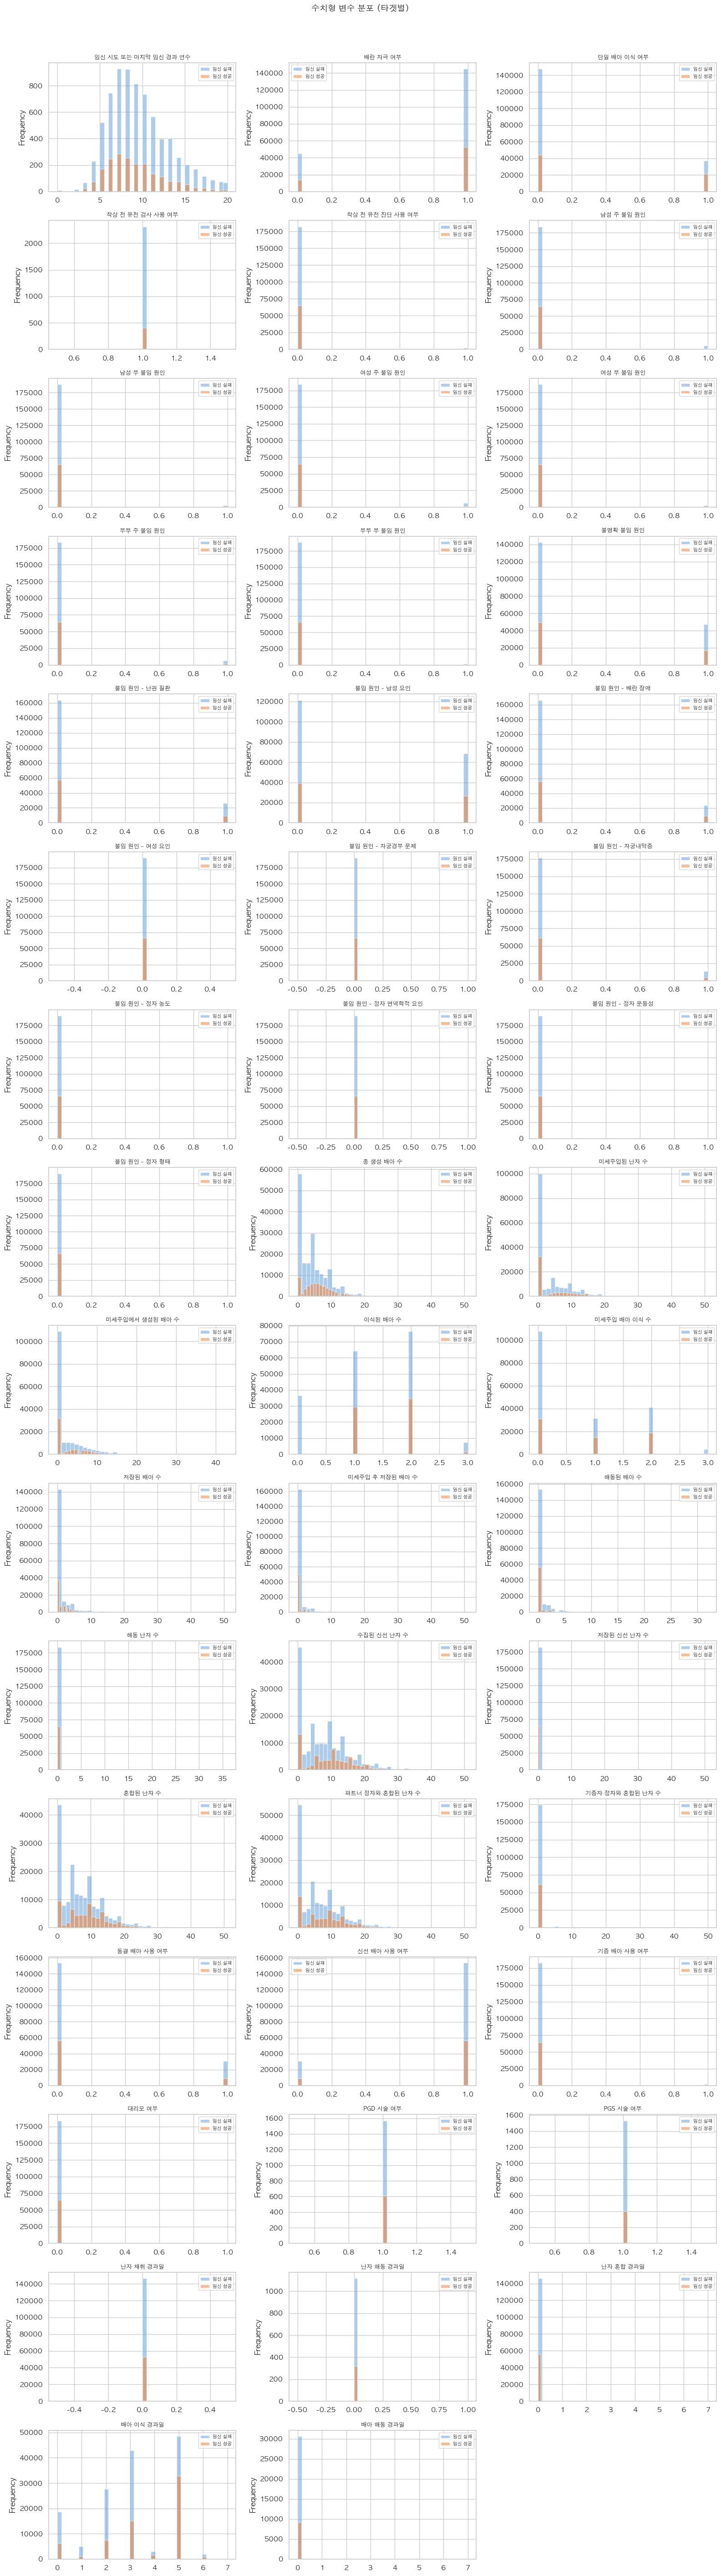

In [10]:
n_cols_plot = 3
n_rows_plot = (len(num_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, n_rows_plot * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for label, color in zip([0, 1], ['#5B9BD5', '#ED7D31']):
        subset = train.loc[train[TARGET] == label, col].dropna()
        subset.plot.hist(ax=ax, alpha=0.5, bins=40, color=color,
                         label=f'임신 {"성공" if label else "실패"}')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('수치형 변수 분포 (타겟별)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
mean_by_target = train.groupby(TARGET)[num_cols].mean().T
mean_by_target.columns = ['실패(0)', '성공(1)']
mean_by_target['차이(성공-실패)'] = mean_by_target['성공(1)'] - mean_by_target['실패(0)']
mean_by_target.sort_values('차이(성공-실패)', ascending=False).round(3)

,실패(0),성공(1),차이(성공-실패)
혼합된 난자 수,7.253,8.958,1.705
파트너 정자와 혼합된 난자 수,6.699,8.259,1.559
총 생성 배아 수,4.655,6.206,1.551
수집된 신선 난자 수,8.202,9.584,1.382
미세주입된 난자 수,3.936,4.834,0.898
미세주입에서 생성된 배아 수,2.624,3.465,0.841
배아 이식 경과일,3.085,3.638,0.553
이식된 배아 수,1.296,1.572,0.277
저장된 배아 수,1.132,1.337,0.205
미세주입 배아 이식 수,0.685,0.836,0.151


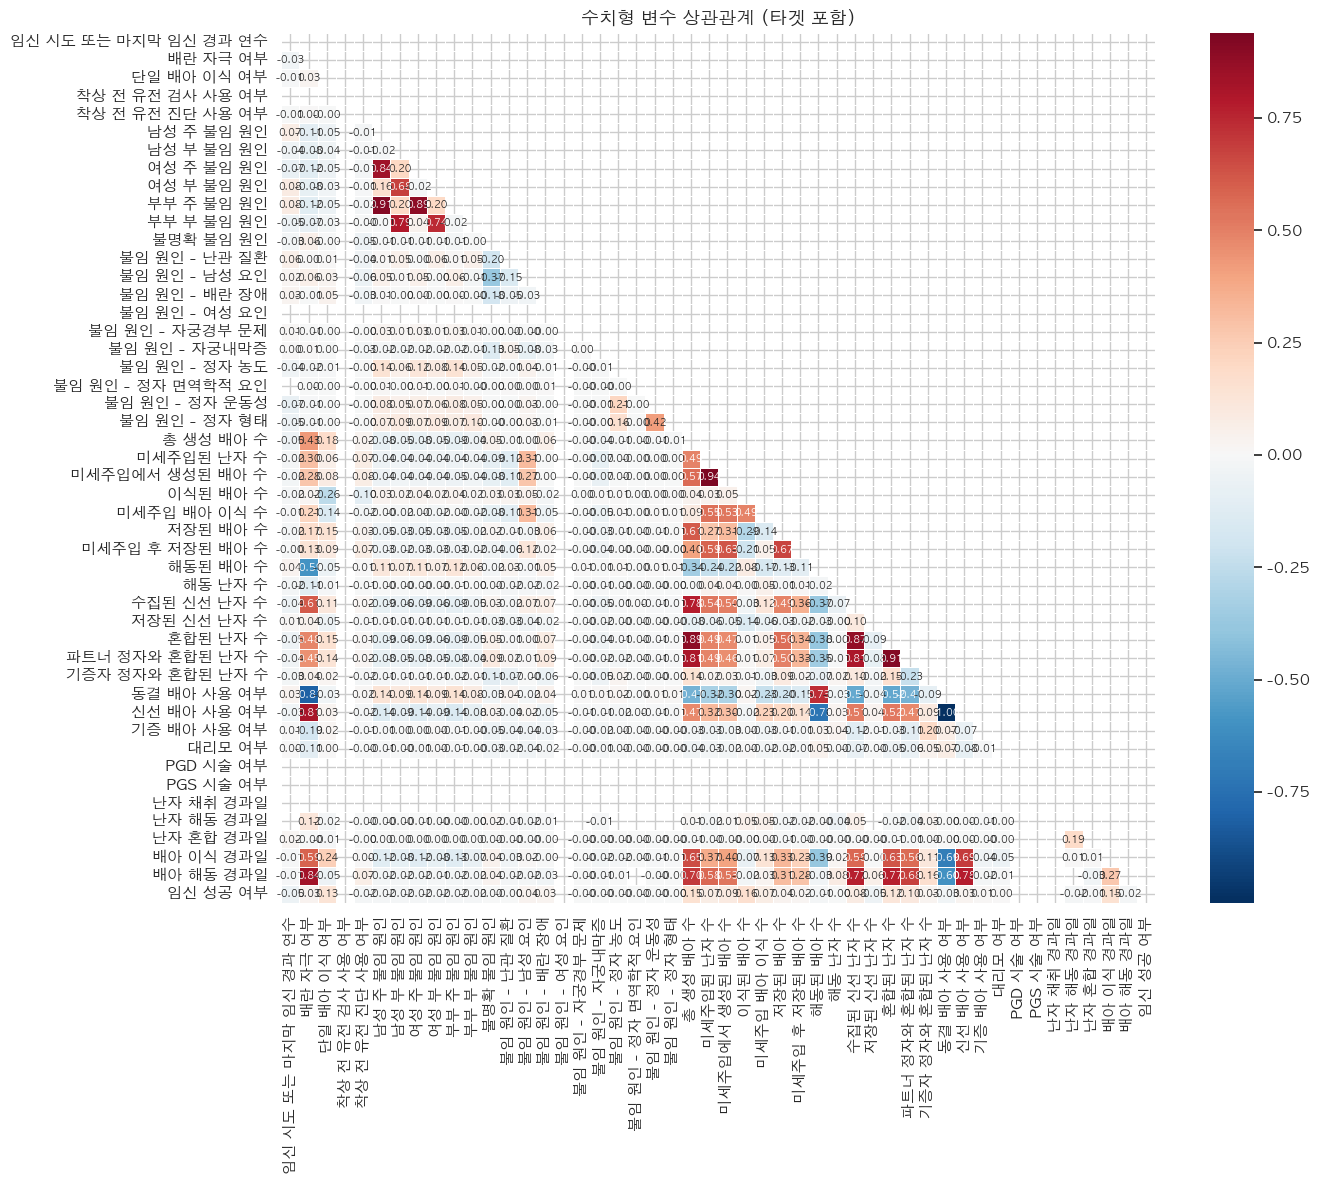

In [12]:
corr = train[num_cols + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('수치형 변수 상관관계 (타겟 포함)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. 범주형 변수 분석

In [13]:
cat_summary = pd.DataFrame({
    '유니크 값 수': train[cat_cols].nunique(),
    '결측 수': train[cat_cols].isnull().sum(),
    '결측률(%)': (train[cat_cols].isnull().sum() / len(train) * 100).round(2)
}).sort_values('유니크 값 수', ascending=False)
cat_summary

,유니크 값 수,결측 수,결측률(%)
특정 시술 유형,24,2,0.00
배아 생성 주요 이유,13,6291,2.45
시술 시기 코드,7,0,0.00
IVF 시술 횟수,7,0,0.00
총 출산 횟수,7,0,0.00
IVF 임신 횟수,7,0,0.00
시술 당시 나이,7,0,0.00
DI 시술 횟수,7,0,0.00
총 임신 횟수,7,0,0.00
클리닉 내 총 시술 횟수,7,0,0.00


In [ ]:
# 배아 생성 주요 이유: 명세상 "복수 선택 가능" → 쉼표 구분 조합을 개별 항목으로 분리 집계
print('=== 배아 생성 주요 이유 — 복수 선택 항목별 분석 ===')
print('(groupby 단순 집계는 조합 문자열을 하나의 범주로 취급하므로 오분석 발생)')
print('→ 각 행의 복수 선택을 개별 항목으로 분리하여 재집계\n')

REASON_COL = '배아 생성 주요 이유'

exploded = (
    train[[REASON_COL, TARGET]]
    .dropna(subset=[REASON_COL])
    .copy()
)
exploded[REASON_COL] = exploded[REASON_COL].str.split(', ')
exploded = exploded.explode(REASON_COL)

item_stats = exploded.groupby(REASON_COL)[TARGET].agg(['mean', 'count'])
item_stats.columns = ['성공률', '건수']
item_stats['성공률'] = item_stats['성공률'] * 100
item_stats = item_stats.sort_values('성공률', ascending=False)

print(item_stats.round(2).to_string())

overall_rate = train[TARGET].mean() * 100
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#ED7D31' if v > overall_rate else '#5B9BD5' for v in item_stats['성공률']]
bars = ax.barh(item_stats.index[::-1], item_stats['성공률'][::-1], color=colors[::-1])
ax.axvline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'전체 평균 {overall_rate:.1f}%')
ax.set_xlabel('임신 성공률 (%)')
ax.set_title('배아 생성 주요 이유 — 항목별 성공률 (복수 선택 분리 집계)')
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars, item_stats.iloc[::-1].iterrows()):
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{w:.1f}%  (n={int(row["건수"]):,})', va='center', fontsize=8)
plt.tight_layout()
plt.show()

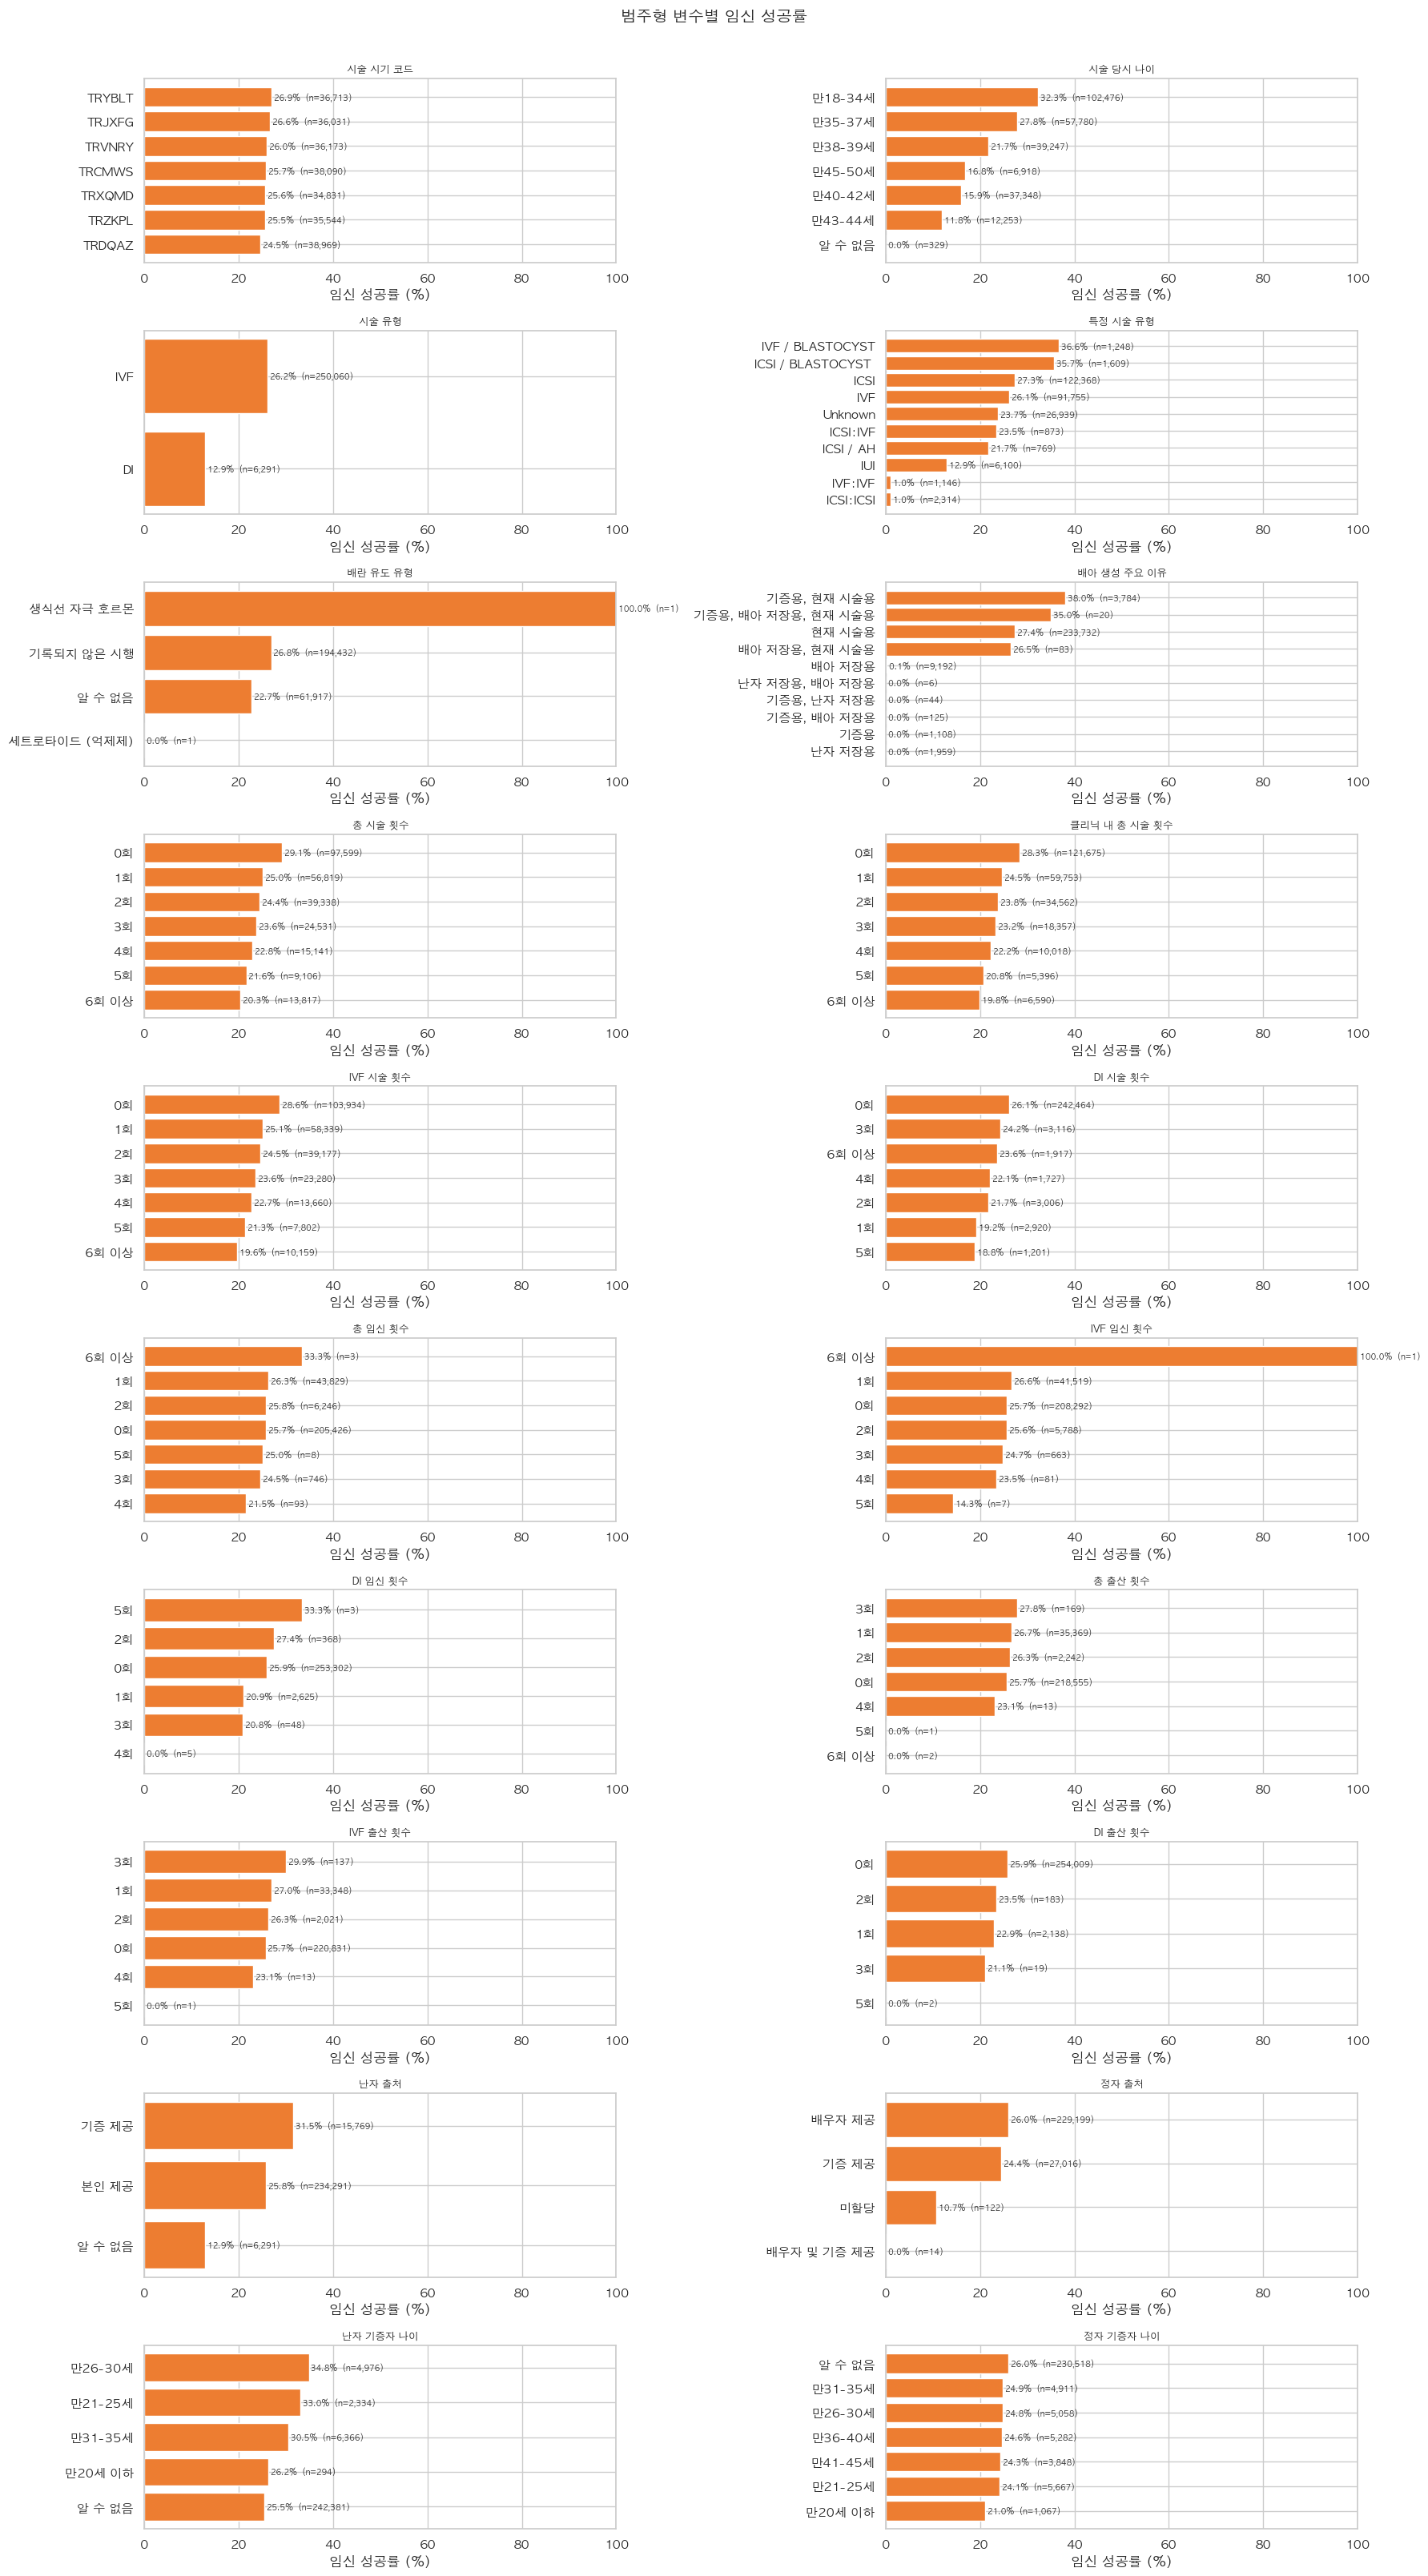

In [14]:
def plot_cat_success_rate(col, ax, top_n=10):
    grouped = train.groupby(col)[TARGET].agg(['mean', 'count']).reset_index()
    grouped.columns = [col, '성공률', '건수']
    grouped = grouped.nlargest(top_n, '건수')
    grouped = grouped.sort_values('성공률', ascending=True)

    bars = ax.barh(grouped[col].astype(str), grouped['성공률'] * 100, color='#ED7D31')
    ax.set_xlim(0, 100)
    ax.set_xlabel('임신 성공률 (%)')
    ax.set_title(col, fontsize=9)
    for bar, cnt in zip(bars, grouped['건수']):
        w = bar.get_width()
        ax.text(w + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{w:.1f}%  (n={cnt:,})', va='center', fontsize=7)

n_cols_plot = 2
n_rows_plot = (len(cat_cols) + 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, n_rows_plot * 3.2))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    plot_cat_success_rate(col, axes[i])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('범주형 변수별 임신 성공률', fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

## 6. 주요 피처별 심층 분석

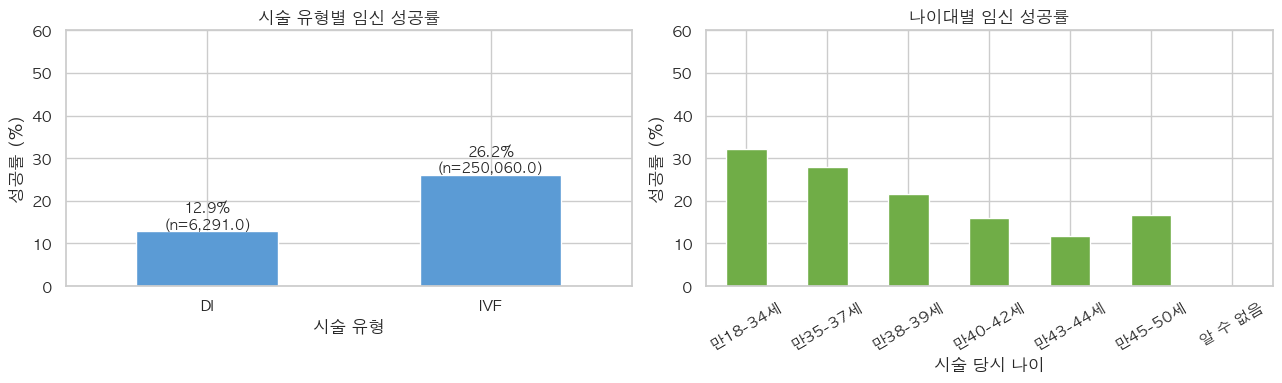

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ivf_di = train.groupby('시술 유형')[TARGET].agg(['mean', 'count'])
ivf_di.columns = ['성공률', '건수']
ivf_di['성공률'] = ivf_di['성공률'] * 100
ivf_di[['성공률']].plot(kind='bar', ax=axes[0], legend=False, color=['#5B9BD5', '#ED7D31'])
axes[0].set_title('시술 유형별 임신 성공률')
axes[0].set_ylabel('성공률 (%)')
axes[0].set_ylim(0, 60)
axes[0].tick_params(axis='x', rotation=0)
for i, (_, row) in enumerate(ivf_di.iterrows()):
    axes[0].text(i, row['성공률'] + 0.5, f"{row['성공률']:.1f}%\n(n={row['건수']:,})",
                 ha='center', fontsize=10)

age_order = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세', '알 수 없음']
age_rate = train.groupby('시술 당시 나이')[TARGET].mean() * 100
age_rate = age_rate.reindex([a for a in age_order if a in age_rate.index])
age_rate.plot(kind='bar', ax=axes[1], color='#70AD47')
axes[1].set_title('나이대별 임신 성공률')
axes[1].set_ylabel('성공률 (%)')
axes[1].set_ylim(0, 60)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

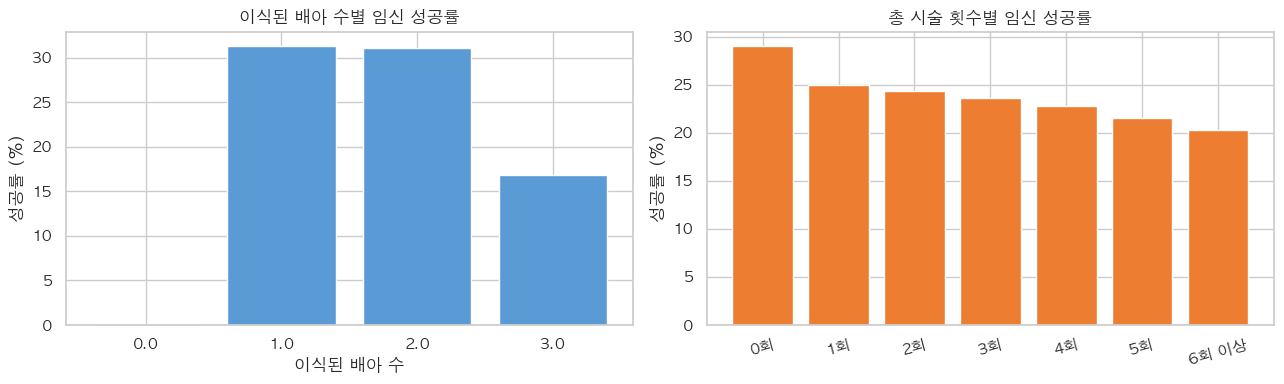

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

emb_rate = train.groupby('이식된 배아 수')[TARGET].agg(['mean', 'count'])
emb_rate.columns = ['성공률', '건수']
emb_rate = emb_rate[emb_rate['건수'] >= 100]
emb_rate['성공률'] = emb_rate['성공률'] * 100
axes[0].bar(emb_rate.index.astype(str), emb_rate['성공률'], color='#5B9BD5')
axes[0].set_title('이식된 배아 수별 임신 성공률')
axes[0].set_xlabel('이식된 배아 수')
axes[0].set_ylabel('성공률 (%)')

tries_order = ['0회', '1회', '2회', '3회', '4회', '5회', '6회 이상']
tries_rate = train.groupby('총 시술 횟수')[TARGET].mean() * 100
tries_rate = tries_rate.reindex([t for t in tries_order if t in tries_rate.index])
axes[1].bar(tries_rate.index, tries_rate.values, color='#ED7D31')
axes[1].set_title('총 시술 횟수별 임신 성공률')
axes[1].set_ylabel('성공률 (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

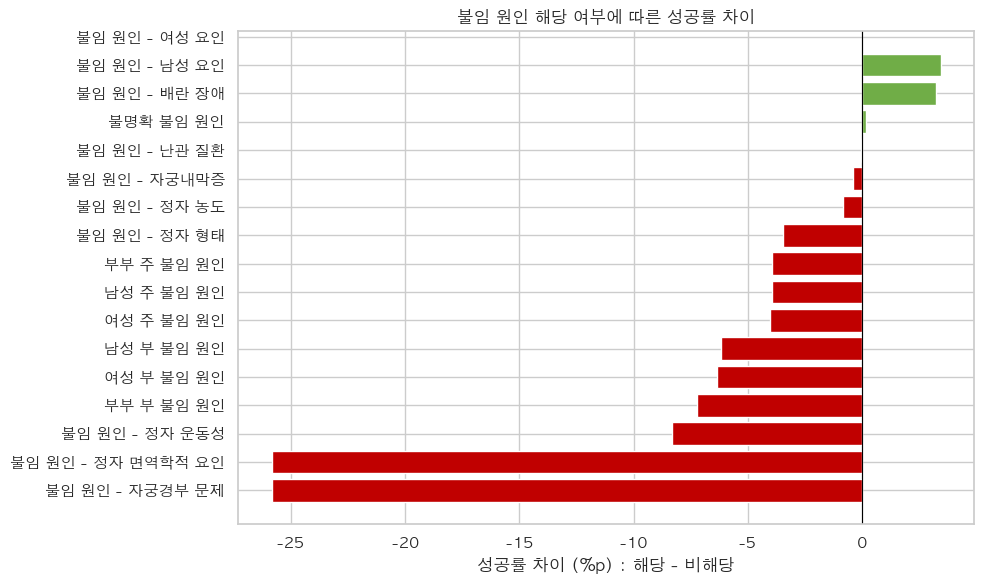

                    해당(1)  비해당(0)  차이(해당-비해당)
불임 원인 - 자궁경부 문제      0.00   25.84      -25.84
불임 원인 - 정자 면역학적 요인   0.00   25.83      -25.83
불임 원인 - 정자 운동성      17.53   25.84       -8.31
부부 부 불임 원인          18.69   25.90       -7.21
여성 부 불임 원인          19.58   25.91       -6.33
남성 부 불임 원인          19.75   25.92       -6.17
여성 주 불임 원인          21.91   25.96       -4.04
남성 주 불임 원인          22.00   25.95       -3.95
부부 주 불임 원인          22.02   25.97       -3.94
불임 원인 - 정자 형태       22.38   25.84       -3.46
불임 원인 - 정자 농도       25.00   25.84       -0.84
불임 원인 - 자궁내막증       25.48   25.86       -0.38
불임 원인 - 난관 질환       25.78   25.84       -0.07
불명확 불임 원인           25.95   25.80        0.15
불임 원인 - 배란 장애       28.66   25.41        3.25
불임 원인 - 남성 요인       27.99   24.56        3.43
불임 원인 - 여성 요인         NaN   25.83         NaN


In [17]:
infertility_cols = [c for c in num_cols if '불임 원인' in c]

infertility_rate = {}
for col in infertility_cols:
    rate_1 = train.loc[train[col] == 1, TARGET].mean()
    rate_0 = train.loc[train[col] == 0, TARGET].mean()
    infertility_rate[col] = {'해당(1)': rate_1 * 100, '비해당(0)': rate_0 * 100}

inf_df = pd.DataFrame(infertility_rate).T
inf_df['차이(해당-비해당)'] = inf_df['해당(1)'] - inf_df['비해당(0)']
inf_df = inf_df.sort_values('차이(해당-비해당)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#C00000' if v < 0 else '#70AD47' for v in inf_df['차이(해당-비해당)']]
ax.barh(inf_df.index, inf_df['차이(해당-비해당)'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('성공률 차이 (%p) : 해당 - 비해당')
ax.set_title('불임 원인 해당 여부에 따른 성공률 차이')
plt.tight_layout()
plt.show()

print(inf_df.round(2).to_string())

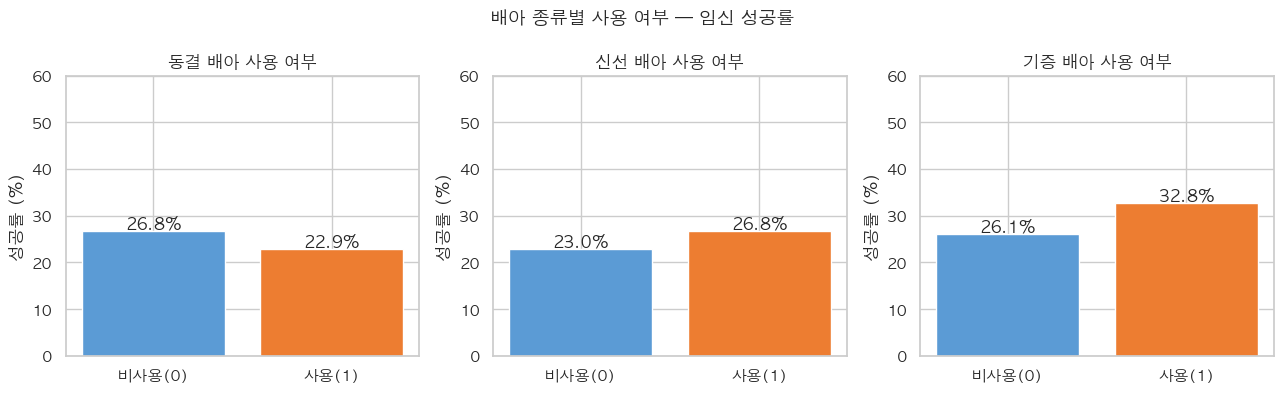

In [18]:
embryo_type_cols = ['동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, embryo_type_cols):
    rate = train.groupby(col)[TARGET].mean() * 100
    ax.bar(['비사용(0)', '사용(1)'], rate.values, color=['#5B9BD5', '#ED7D31'])
    ax.set_title(col)
    ax.set_ylabel('성공률 (%)')
    ax.set_ylim(0, 60)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.suptitle('배아 종류별 사용 여부 — 임신 성공률', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Train / Test 분포 비교 (데이터 드리프트 확인)

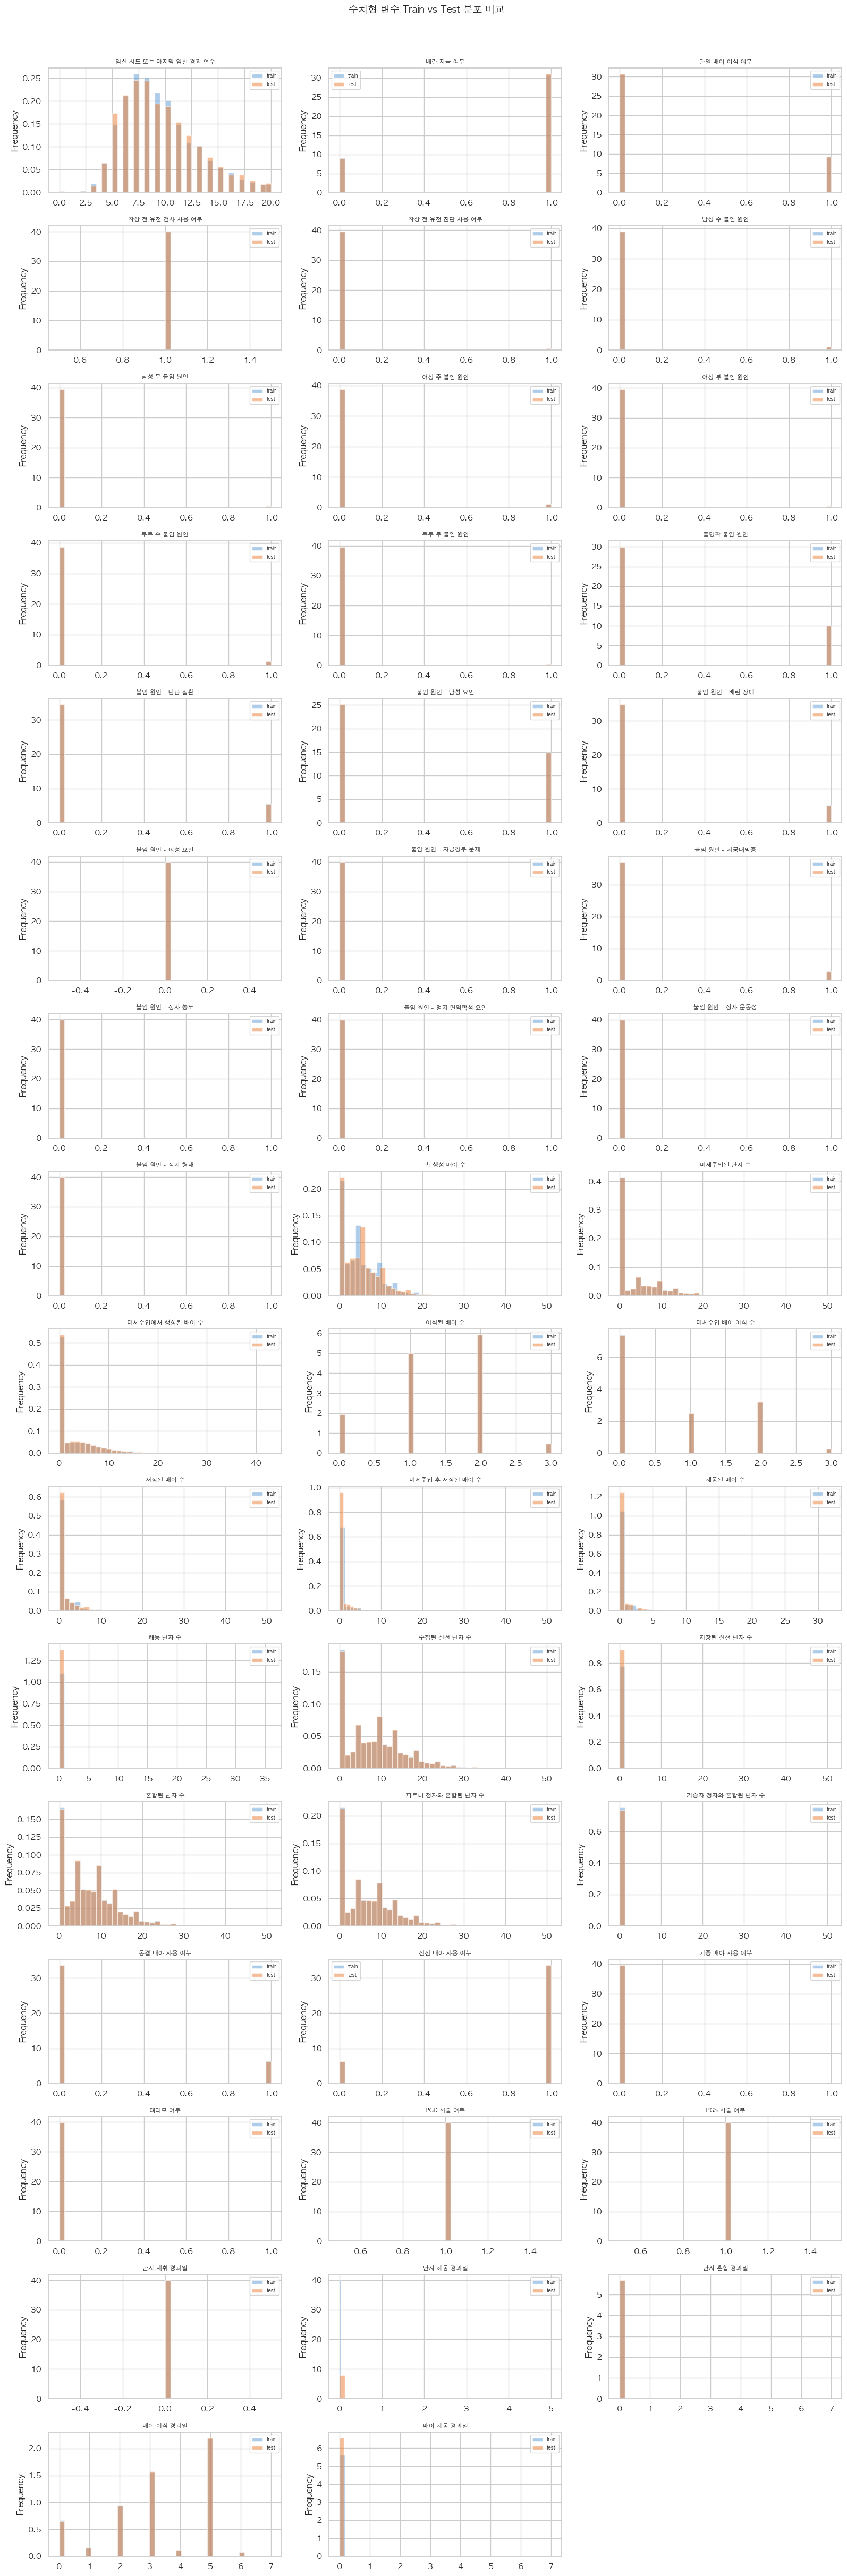

In [19]:
n_cols_plot = 3
n_rows_plot = (len(num_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, n_rows_plot * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    train[col].dropna().plot.hist(ax=ax, bins=40, alpha=0.5,
                                   color='#5B9BD5', label='train', density=True)
    test[col].dropna().plot.hist(ax=ax, bins=40, alpha=0.5,
                                  color='#ED7D31', label='test', density=True)
    ax.set_title(col, fontsize=8)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('수치형 변수 Train vs Test 분포 비교', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. EDA 핵심 요약

In [ ]:
print('=== EDA 핵심 요약 ===')
print()

pos_rate = train[TARGET].mean() * 100
neg_rate = 100 - pos_rate
# 실패:성공 비율 = (1-성공률) / 성공률
imbalance_ratio = neg_rate / pos_rate
print(f'[클래스 불균형] 임신 성공률: {pos_rate:.1f}%  →  실패:성공 비율 약 {imbalance_ratio:.1f}:1')
print(f'                실패 {(train[TARGET]==0).sum():,}건 / 성공 {(train[TARGET]==1).sum():,}건')
print()

miss_count = (train.isnull().sum() > 0).sum()
print(f'[결측치] 결측 있는 컬럼 수: {miss_count}개')
print()

print(f'[피처] 수치형 {len(num_cols)}개 / 범주형 {len(cat_cols)}개')
print()

target_corr = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('[수치형 피처 중 타겟 상관관계 상위 5]')
for col, val in target_corr.head(5).items():
    print(f'  {col}: {val:.4f}')
print()

print('[이진 플래그 피처 중 성공률 차이 큰 항목 Top 5]')
binary_num = [c for c in num_cols if set(train[c].dropna().unique()).issubset({0, 1})]
binary_rates = {}
for col in binary_num:
    r1 = train.loc[train[col] == 1, TARGET].mean()
    r0 = train.loc[train[col] == 0, TARGET].mean()
    if not pd.isna(r1) and not pd.isna(r0):
        binary_rates[col] = abs(r1 - r0)
top_binary = sorted(binary_rates.items(), key=lambda x: x[1], reverse=True)[:5]
for col, diff in top_binary:
    print(f'  {col}: 차이 {diff*100:.2f}%p')